<a href="https://colab.research.google.com/github/brbvisayas/folds/blob/main/AlphaFold2_top6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://raw.githubusercontent.com/sokrypton/ColabFold/main/.github/ColabFold_Marv_Logo_Small.png" height="200" align="right" style="height:240px">

##ColabFold v1.5.5: AlphaFold2 using MMseqs2

Easy to use protein structure and complex prediction using [AlphaFold2](https://www.nature.com/articles/s41586-021-03819-2) and [Alphafold2-multimer](https://www.biorxiv.org/content/10.1101/2021.10.04.463034v1). Sequence alignments/templates are generated through [MMseqs2](mmseqs.com) and [HHsearch](https://github.com/soedinglab/hh-suite). For more details, see <a href="#Instructions">bottom</a> of the notebook, checkout the [ColabFold GitHub](https://github.com/sokrypton/ColabFold) and [Nature Protocols](https://www.nature.com/articles/s41596-024-01060-5).

Old versions: [v1.4](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.4.0/AlphaFold2.ipynb), [v1.5.1](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.5.1/AlphaFold2.ipynb), [v1.5.2](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.5.2/AlphaFold2.ipynb), [v1.5.3-patch](https://colab.research.google.com/github/sokrypton/ColabFold/blob/56c72044c7d51a311ca99b953a71e552fdc042e1/AlphaFold2.ipynb)

[Mirdita M, Schütze K, Moriwaki Y, Heo L, Ovchinnikov S, Steinegger M. ColabFold: Making protein folding accessible to all.
*Nature Methods*, 2022](https://www.nature.com/articles/s41592-022-01488-1)

In [42]:
#@title Input protein sequence(s), then hit `Runtime` -> `Run all`
from google.colab import files
import os
import re
import hashlib
import random

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

query_sequence = 'QVQLQESGGGLVQAGGSLRLSCAASGNISRVYYMGWYRQAPGKERELVASISSGTSTYYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAVTYAVQSPQNYVHSYWGQGTQVTVSS' #@param {type:"string"}
#@markdown  - Use `:` to specify inter-protein chainbreaks for **modeling complexes** (supports homo- and hetro-oligomers). For example **PI...SK:PI...SK** for a homodimer
jobname = 'top6' #@param {type:"string"}
# number of models to use
num_relax = 5 #@param [0, 1, 5] {type:"raw"}
#@markdown - specify how many of the top ranked structures to relax using amber
template_mode = "pdb100" #@param ["none", "pdb100","custom"]
#@markdown - `none` = no template information is used. `pdb100` = detect templates in pdb100 (see [notes](#pdb100)). `custom` - upload and search own templates (PDB or mmCIF format, see [notes](#custom_templates))

use_amber = num_relax > 0

# remove whitespaces
query_sequence = "".join(query_sequence.split())

basejobname = "".join(jobname.split())
basejobname = re.sub(r'\W+', '', basejobname)
jobname = add_hash(basejobname, query_sequence)

# check if directory with jobname exists
def check(folder):
  if os.path.exists(folder):
    return False
  else:
    return True
if not check(jobname):
  n = 0
  while not check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

# make directory to save results
os.makedirs(jobname, exist_ok=True)

# save queries
queries_path = os.path.join(jobname, f"{jobname}.csv")
with open(queries_path, "w") as text_file:
  text_file.write(f"id,sequence\n{jobname},{query_sequence}")

if template_mode == "pdb100":
  use_templates = True
  custom_template_path = None
elif template_mode == "custom":
  custom_template_path = os.path.join(jobname,f"template")
  os.makedirs(custom_template_path, exist_ok=True)
  uploaded = files.upload()
  use_templates = True
  for fn in uploaded.keys():
    os.rename(fn,os.path.join(custom_template_path,fn))
else:
  custom_template_path = None
  use_templates = False

print("jobname",jobname)
print("sequence",query_sequence)
print("length",len(query_sequence.replace(":","")))

jobname top6_6f43b
sequence QVQLQESGGGLVQAGGSLRLSCAASGNISRVYYMGWYRQAPGKERELVASISSGTSTYYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAVTYAVQSPQNYVHSYWGQGTQVTVSS
length 122


In [43]:
#@title Install dependencies
%%time
import os
USE_AMBER = use_amber
USE_TEMPLATES = use_templates
PYTHON_VERSION = python_version

if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  # hack to fix TF crash
  os.system("rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so")
  os.system("touch COLABFOLD_READY")

if USE_AMBER or USE_TEMPLATES:
  if not os.path.isfile("CONDA_READY"):
    print("installing conda...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh")
    os.system("bash Miniforge3-Linux-x86_64.sh -bfp /usr/local")
    os.system("mamba config --set auto_update_conda false")
    os.system("touch CONDA_READY")

if USE_TEMPLATES and not os.path.isfile("HH_READY") and USE_AMBER and not os.path.isfile("AMBER_READY"):
  print("installing hhsuite and amber...")
  os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
  os.system("touch HH_READY")
  os.system("touch AMBER_READY")
else:
  if USE_TEMPLATES and not os.path.isfile("HH_READY"):
    print("installing hhsuite...")
    os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
    os.system("touch HH_READY")
  if USE_AMBER and not os.path.isfile("AMBER_READY"):
    print("installing amber...")
    os.system(f"mamba install -y -c conda-forge openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
    os.system("touch AMBER_READY")

CPU times: user 53 µs, sys: 0 ns, total: 53 µs
Wall time: 56.7 µs


In [44]:
#@markdown ### MSA options (custom MSA upload, single sequence, pairing mode)
msa_mode = "mmseqs2_uniref_env" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.

# decide which a3m to use
if "mmseqs2" in msa_mode:
  a3m_file = os.path.join(jobname,f"{jobname}.a3m")

elif msa_mode == "custom":
  a3m_file = os.path.join(jobname,f"{jobname}.custom.a3m")
  if not os.path.isfile(a3m_file):
    custom_msa_dict = files.upload()
    custom_msa = list(custom_msa_dict.keys())[0]
    header = 0
    import fileinput
    for line in fileinput.FileInput(custom_msa,inplace=1):
      if line.startswith(">"):
         header = header + 1
      if not line.rstrip():
        continue
      if line.startswith(">") == False and header == 1:
         query_sequence = line.rstrip()
      print(line, end='')

    os.rename(custom_msa, a3m_file)
    queries_path=a3m_file
    print(f"moving {custom_msa} to {a3m_file}")

else:
  a3m_file = os.path.join(jobname,f"{jobname}.single_sequence.a3m")
  with open(a3m_file, "w") as text_file:
    text_file.write(">1\n%s" % query_sequence)

In [45]:
#@markdown ### Advanced settings
model_type = "deepfold_v1" #@param ["auto", "alphafold2_ptm", "alphafold2_multimer_v1", "alphafold2_multimer_v2", "alphafold2_multimer_v3", "deepfold_v1", "alphafold2"]
#@markdown - if `auto` selected, will use `alphafold2_ptm` for monomer prediction and `alphafold2_multimer_v3` for complex prediction.
#@markdown Any of the mode_types can be used (regardless if input is monomer or complex).
num_recycles = "6" #@param ["auto", "0", "1", "3", "6", "12", "24", "48"]
#@markdown - if `auto` selected, will use `num_recycles=20` if `model_type=alphafold2_multimer_v3`, else `num_recycles=3` .
recycle_early_stop_tolerance = "auto" #@param ["auto", "0.0", "0.5", "1.0"]
#@markdown - if `auto` selected, will use `tol=0.5` if `model_type=alphafold2_multimer_v3` else `tol=0.0`.
relax_max_iterations = 2000 #@param [0, 200, 2000] {type:"raw"}
#@markdown - max amber relax iterations, `0` = unlimited (AlphaFold2 default, can take very long)
pairing_strategy = "greedy" #@param ["greedy", "complete"] {type:"string"}
#@markdown - `greedy` = pair any taxonomically matching subsets, `complete` = all sequences have to match in one line.
calc_extra_ptm = True #@param {type:"boolean"}
#@markdown - return pairwise chain iptm/actifptm

#@markdown #### Sample settings
#@markdown -  enable dropouts and increase number of seeds to sample predictions from uncertainty of the model.
#@markdown -  decrease `max_msa` to increase uncertainity
max_msa = "auto" #@param ["auto", "512:1024", "256:512", "64:128", "32:64", "16:32"]
num_seeds = 4 #@param [1,2,4,8,16] {type:"raw"}
use_dropout = True #@param {type:"boolean"}

num_recycles = None if num_recycles == "auto" else int(num_recycles)
recycle_early_stop_tolerance = None if recycle_early_stop_tolerance == "auto" else float(recycle_early_stop_tolerance)
if max_msa == "auto": max_msa = None

#@markdown #### Save settings
save_all = False #@param {type:"boolean"}
save_recycles = False #@param {type:"boolean"}
save_to_google_drive = False #@param {type:"boolean"}
#@markdown -  if the save_to_google_drive option was selected, the result zip will be uploaded to your Google Drive
dpi = 200 #@param {type:"integer"}
#@markdown - set dpi for image resolution

if save_to_google_drive:
  from pydrive2.drive import GoogleDrive
  from pydrive2.auth import GoogleAuth
  from google.colab import auth
  from oauth2client.client import GoogleCredentials
  auth.authenticate_user()
  gauth = GoogleAuth()
  gauth.credentials = GoogleCredentials.get_application_default()
  drive = GoogleDrive(gauth)
  print("You are logged into Google Drive and are good to go!")

#@markdown Don't forget to hit `Runtime` -> `Run all` after updating the form.

2026-03-06 15:06:10,755 Running on GPU
2026-03-06 15:06:10,756 Calculating extra pTM is not supported for single chain prediction, skipping it.
2026-03-06 15:06:10,761 Found 9 citations for tools or databases
2026-03-06 15:06:10,761 Query 1/1: top6_6f43b (length 122)


PENDING:   0%|          | 0/150 [elapsed: 00:00 remaining: ?]

2026-03-06 15:06:11,329 Sleeping for 9s. Reason: PENDING


RUNNING:   6%|▌         | 9/150 [elapsed: 00:10 remaining: 02:37]

2026-03-06 15:06:20,824 Sleeping for 9s. Reason: RUNNING


...

2026-03-06 15:06:30,307 Sleeping for 9s. Reason: RUNNING


RUNNING:  18%|█▊        | 27/150 [elapsed: 00:29 remaining: 02:11]

2026-03-06 15:06:39,793 Sleeping for 9s. Reason: RUNNING


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:39 remaining: 00:00]


2026-03-06 15:07:08,015 Sequence 0 found templates: ['7yaj_C', '7mjk_D', '7mjl_H', '7q9j_H', '4tsb_H', '6o3c_B', '4tsa_H', '7k8n_A', '5vnw_D', '7k8m_A', '7d0c_G', '4tsc_H', '7rth_H', '5hvg_B', '7cho_H', '7e3o_H', '7sl9_B', '7cho_B', '7str_H']


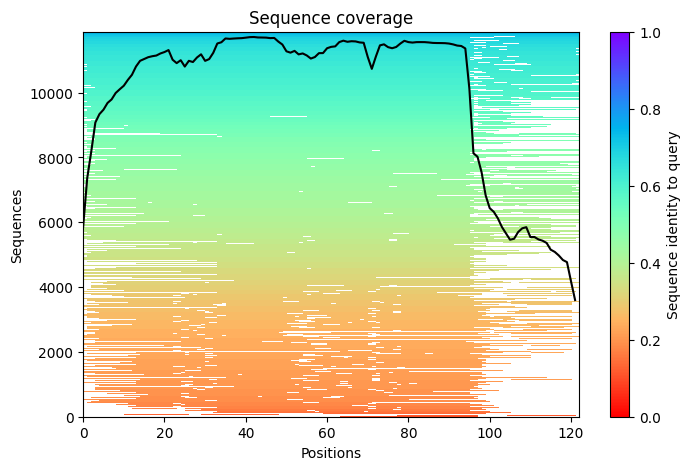

2026-03-06 15:07:10,012 Setting max_seq=512, max_extra_seq=5120
2026-03-06 15:08:11,049 deepfold_v1_model_1_seed_000 recycle=0 pLDDT=91.9
2026-03-06 15:08:56,600 deepfold_v1_model_1_seed_000 recycle=1 pLDDT=92.1 tol=0.198
2026-03-06 15:09:05,835 deepfold_v1_model_1_seed_000 recycle=2 pLDDT=91.9 tol=0.126
2026-03-06 15:09:15,108 deepfold_v1_model_1_seed_000 recycle=3 pLDDT=91.5 tol=0.095
2026-03-06 15:09:24,342 deepfold_v1_model_1_seed_000 recycle=4 pLDDT=91.5 tol=0.138
2026-03-06 15:09:33,343 deepfold_v1_model_1_seed_000 recycle=5 pLDDT=91.2 tol=0.101
2026-03-06 15:09:42,230 deepfold_v1_model_1_seed_000 recycle=6 pLDDT=91.8 tol=0.145
2026-03-06 15:09:42,231 deepfold_v1_model_1_seed_000 took 138.5s (6 recycles)


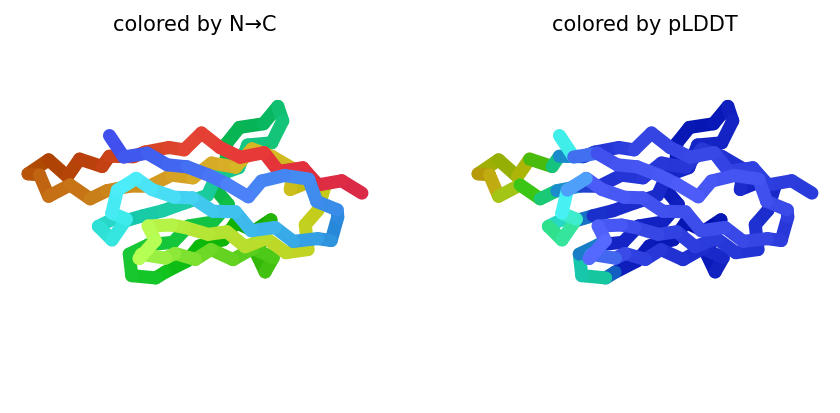

2026-03-06 15:09:51,166 deepfold_v1_model_2_seed_000 recycle=0 pLDDT=90.5
2026-03-06 15:10:00,031 deepfold_v1_model_2_seed_000 recycle=1 pLDDT=90.6 tol=0.245
2026-03-06 15:10:08,963 deepfold_v1_model_2_seed_000 recycle=2 pLDDT=90.4 tol=0.118
2026-03-06 15:10:17,965 deepfold_v1_model_2_seed_000 recycle=3 pLDDT=90 tol=0.0967
2026-03-06 15:10:27,043 deepfold_v1_model_2_seed_000 recycle=4 pLDDT=89.9 tol=0.138
2026-03-06 15:10:36,114 deepfold_v1_model_2_seed_000 recycle=5 pLDDT=89.7 tol=0.105
2026-03-06 15:10:45,157 deepfold_v1_model_2_seed_000 recycle=6 pLDDT=90.4 tol=0.141
2026-03-06 15:10:45,157 deepfold_v1_model_2_seed_000 took 62.8s (6 recycles)


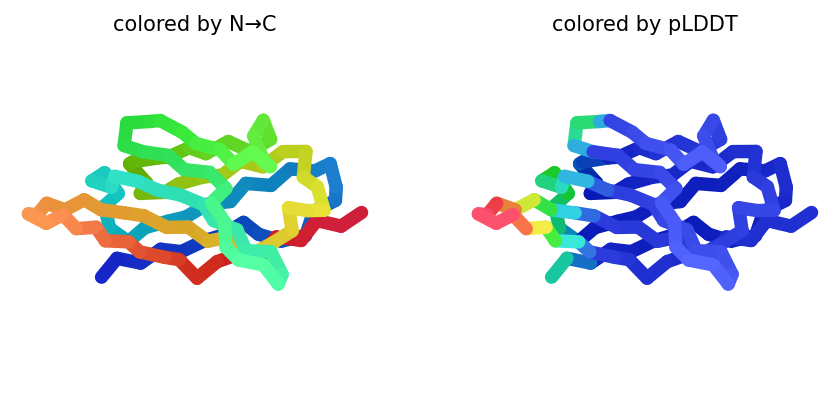

2026-03-06 15:11:19,590 deepfold_v1_model_3_seed_000 recycle=0 pLDDT=89.7
2026-03-06 15:11:53,084 deepfold_v1_model_3_seed_000 recycle=1 pLDDT=90.8 tol=0.469
2026-03-06 15:12:02,163 deepfold_v1_model_3_seed_000 recycle=2 pLDDT=90.5 tol=0.185
2026-03-06 15:12:11,323 deepfold_v1_model_3_seed_000 recycle=3 pLDDT=90.1 tol=0.118
2026-03-06 15:12:20,485 deepfold_v1_model_3_seed_000 recycle=4 pLDDT=90.1 tol=0.11
2026-03-06 15:12:29,472 deepfold_v1_model_3_seed_000 recycle=5 pLDDT=89.9 tol=0.0945
2026-03-06 15:12:38,284 deepfold_v1_model_3_seed_000 recycle=6 pLDDT=90.6 tol=0.135
2026-03-06 15:12:38,285 deepfold_v1_model_3_seed_000 took 113.0s (6 recycles)


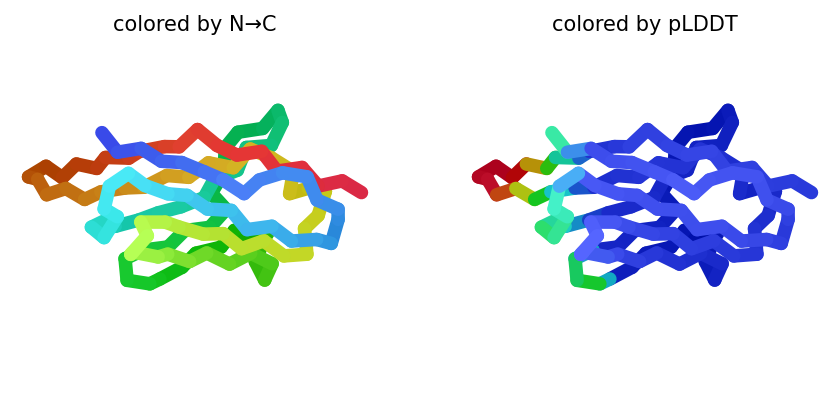

2026-03-06 15:12:47,140 deepfold_v1_model_4_seed_000 recycle=0 pLDDT=89.4
2026-03-06 15:12:55,913 deepfold_v1_model_4_seed_000 recycle=1 pLDDT=90.2 tol=0.455
2026-03-06 15:13:04,718 deepfold_v1_model_4_seed_000 recycle=2 pLDDT=89.9 tol=0.14
2026-03-06 15:13:13,610 deepfold_v1_model_4_seed_000 recycle=3 pLDDT=89.7 tol=0.126
2026-03-06 15:13:22,593 deepfold_v1_model_4_seed_000 recycle=4 pLDDT=89.3 tol=0.121
2026-03-06 15:13:31,611 deepfold_v1_model_4_seed_000 recycle=5 pLDDT=89.3 tol=0.0861
2026-03-06 15:13:40,625 deepfold_v1_model_4_seed_000 recycle=6 pLDDT=90.1 tol=0.145
2026-03-06 15:13:40,626 deepfold_v1_model_4_seed_000 took 62.3s (6 recycles)


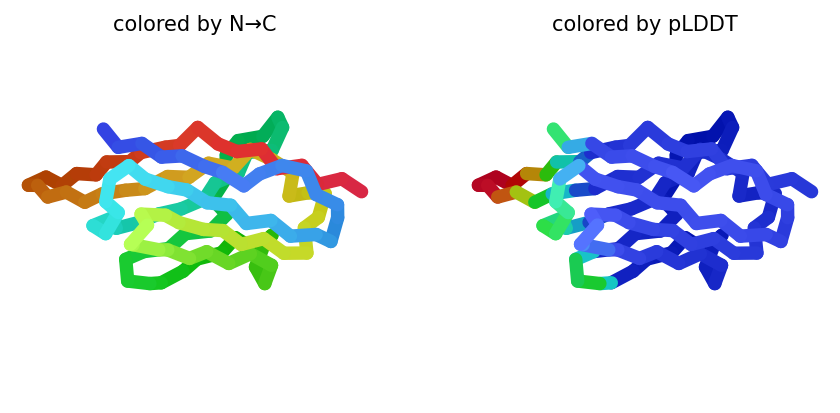

2026-03-06 15:13:49,661 deepfold_v1_model_5_seed_000 recycle=0 pLDDT=89.4
2026-03-06 15:13:58,564 deepfold_v1_model_5_seed_000 recycle=1 pLDDT=90.2 tol=0.504
2026-03-06 15:14:07,430 deepfold_v1_model_5_seed_000 recycle=2 pLDDT=89.6 tol=0.215
2026-03-06 15:14:16,273 deepfold_v1_model_5_seed_000 recycle=3 pLDDT=89.4 tol=0.128
2026-03-06 15:14:25,144 deepfold_v1_model_5_seed_000 recycle=4 pLDDT=89.4 tol=0.107
2026-03-06 15:14:34,027 deepfold_v1_model_5_seed_000 recycle=5 pLDDT=89.4 tol=0.0983
2026-03-06 15:14:42,922 deepfold_v1_model_5_seed_000 recycle=6 pLDDT=90.2 tol=0.16
2026-03-06 15:14:42,922 deepfold_v1_model_5_seed_000 took 62.2s (6 recycles)


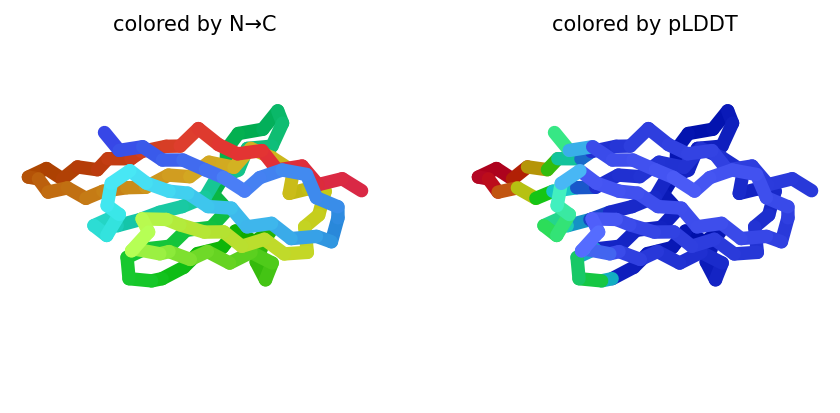

2026-03-06 15:14:59,752 deepfold_v1_model_1_seed_001 recycle=0 pLDDT=90.9
2026-03-06 15:15:08,780 deepfold_v1_model_1_seed_001 recycle=1 pLDDT=91.6 tol=0.426
2026-03-06 15:15:18,007 deepfold_v1_model_1_seed_001 recycle=2 pLDDT=91.9 tol=0.126
2026-03-06 15:15:27,250 deepfold_v1_model_1_seed_001 recycle=3 pLDDT=92.2 tol=0.0846
2026-03-06 15:15:36,323 deepfold_v1_model_1_seed_001 recycle=4 pLDDT=92.5 tol=0.0759
2026-03-06 15:15:45,294 deepfold_v1_model_1_seed_001 recycle=5 pLDDT=92.8 tol=0.0936
2026-03-06 15:15:54,206 deepfold_v1_model_1_seed_001 recycle=6 pLDDT=92 tol=0.0996
2026-03-06 15:15:54,207 deepfold_v1_model_1_seed_001 took 63.5s (6 recycles)


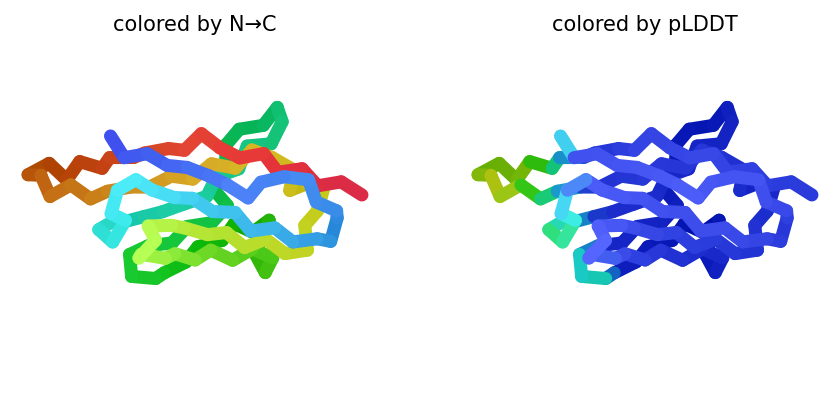

2026-03-06 15:16:03,194 deepfold_v1_model_2_seed_001 recycle=0 pLDDT=89.5
2026-03-06 15:16:12,102 deepfold_v1_model_2_seed_001 recycle=1 pLDDT=90.1 tol=0.366
2026-03-06 15:16:21,055 deepfold_v1_model_2_seed_001 recycle=2 pLDDT=90.4 tol=0.117
2026-03-06 15:16:30,069 deepfold_v1_model_2_seed_001 recycle=3 pLDDT=90.6 tol=0.0925
2026-03-06 15:16:39,094 deepfold_v1_model_2_seed_001 recycle=4 pLDDT=91 tol=0.0803
2026-03-06 15:16:48,137 deepfold_v1_model_2_seed_001 recycle=5 pLDDT=91.4 tol=0.116
2026-03-06 15:16:57,162 deepfold_v1_model_2_seed_001 recycle=6 pLDDT=90.5 tol=0.128
2026-03-06 15:16:57,163 deepfold_v1_model_2_seed_001 took 62.9s (6 recycles)


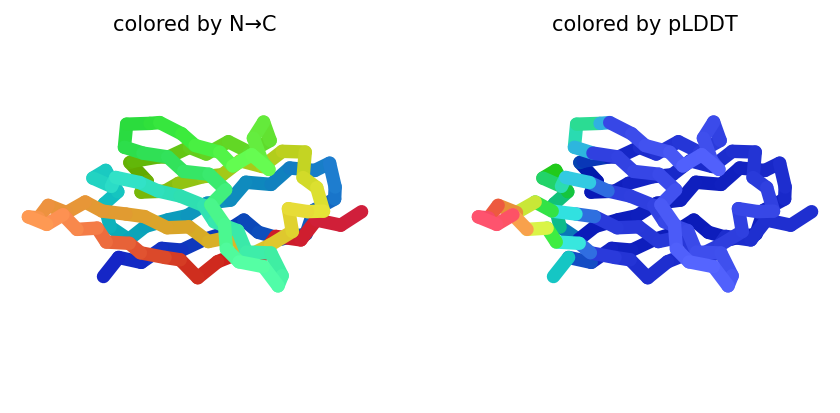

2026-03-06 15:17:06,168 deepfold_v1_model_3_seed_001 recycle=0 pLDDT=88.9
2026-03-06 15:17:15,052 deepfold_v1_model_3_seed_001 recycle=1 pLDDT=92.1 tol=0.706
2026-03-06 15:17:23,911 deepfold_v1_model_3_seed_001 recycle=2 pLDDT=92.1 tol=0.187
2026-03-06 15:17:32,780 deepfold_v1_model_3_seed_001 recycle=3 pLDDT=93.1 tol=0.215
2026-03-06 15:17:41,666 deepfold_v1_model_3_seed_001 recycle=4 pLDDT=93.8 tol=0.077
2026-03-06 15:17:50,578 deepfold_v1_model_3_seed_001 recycle=5 pLDDT=94.1 tol=0.0981
2026-03-06 15:17:59,504 deepfold_v1_model_3_seed_001 recycle=6 pLDDT=94.6 tol=0.092
2026-03-06 15:17:59,505 deepfold_v1_model_3_seed_001 took 62.3s (6 recycles)


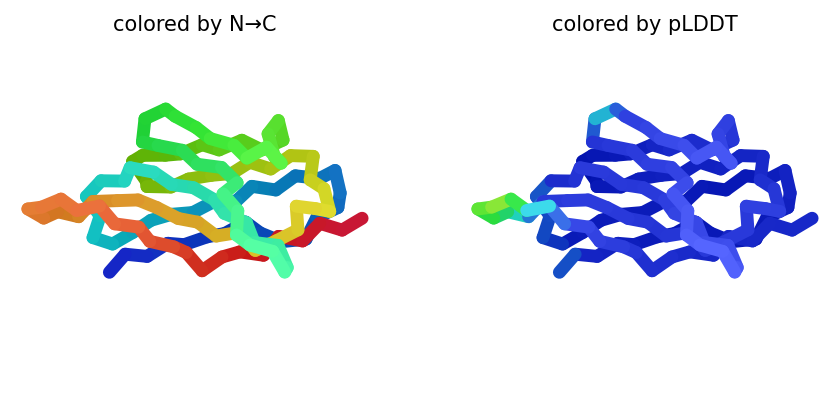

2026-03-06 15:18:08,524 deepfold_v1_model_4_seed_001 recycle=0 pLDDT=87.9
2026-03-06 15:18:17,460 deepfold_v1_model_4_seed_001 recycle=1 pLDDT=91.3 tol=0.77
2026-03-06 15:18:26,392 deepfold_v1_model_4_seed_001 recycle=2 pLDDT=91.2 tol=0.186
2026-03-06 15:18:35,325 deepfold_v1_model_4_seed_001 recycle=3 pLDDT=92.3 tol=0.163
2026-03-06 15:18:44,261 deepfold_v1_model_4_seed_001 recycle=4 pLDDT=92.6 tol=0.0919
2026-03-06 15:18:53,181 deepfold_v1_model_4_seed_001 recycle=5 pLDDT=92.9 tol=0.123
2026-03-06 15:19:02,083 deepfold_v1_model_4_seed_001 recycle=6 pLDDT=93.4 tol=0.0808
2026-03-06 15:19:02,084 deepfold_v1_model_4_seed_001 took 62.5s (6 recycles)


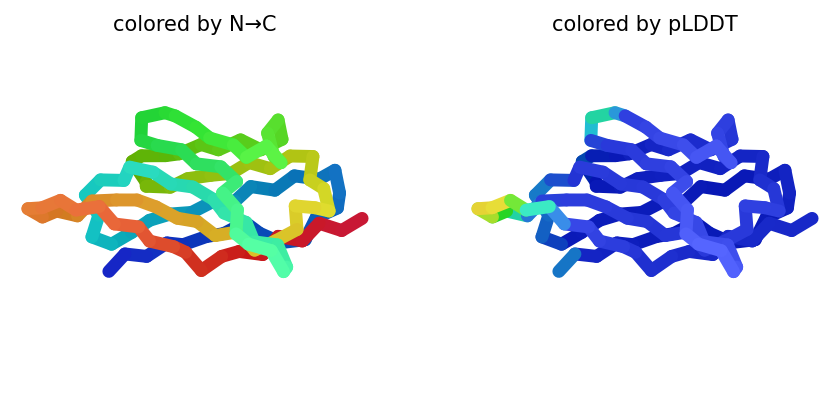

2026-03-06 15:19:11,071 deepfold_v1_model_5_seed_001 recycle=0 pLDDT=88.2
2026-03-06 15:19:19,968 deepfold_v1_model_5_seed_001 recycle=1 pLDDT=91.6 tol=0.797
2026-03-06 15:19:28,868 deepfold_v1_model_5_seed_001 recycle=2 pLDDT=91.9 tol=0.212
2026-03-06 15:19:37,757 deepfold_v1_model_5_seed_001 recycle=3 pLDDT=93.2 tol=0.161
2026-03-06 15:19:46,651 deepfold_v1_model_5_seed_001 recycle=4 pLDDT=93.4 tol=0.101
2026-03-06 15:19:55,550 deepfold_v1_model_5_seed_001 recycle=5 pLDDT=93.7 tol=0.109
2026-03-06 15:20:04,438 deepfold_v1_model_5_seed_001 recycle=6 pLDDT=94.1 tol=0.0859
2026-03-06 15:20:04,439 deepfold_v1_model_5_seed_001 took 62.3s (6 recycles)


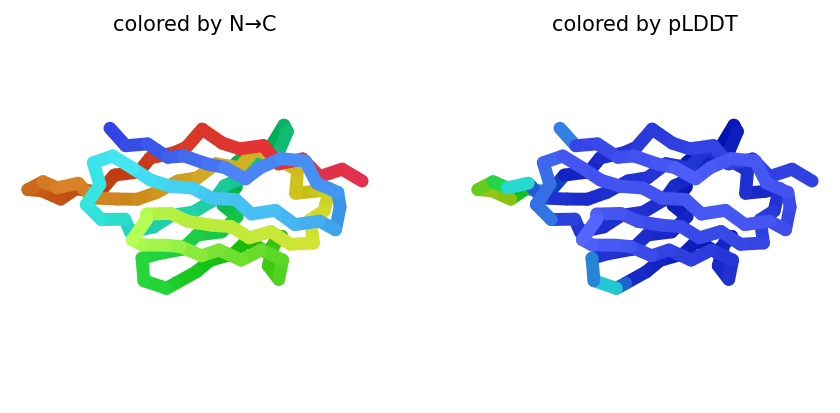

2026-03-06 15:20:20,307 deepfold_v1_model_1_seed_002 recycle=0 pLDDT=91.4
2026-03-06 15:20:29,310 deepfold_v1_model_1_seed_002 recycle=1 pLDDT=92.6 tol=0.202
2026-03-06 15:20:38,543 deepfold_v1_model_1_seed_002 recycle=2 pLDDT=92.1 tol=0.165
2026-03-06 15:20:47,780 deepfold_v1_model_1_seed_002 recycle=3 pLDDT=91.6 tol=0.0753
2026-03-06 15:20:56,824 deepfold_v1_model_1_seed_002 recycle=4 pLDDT=91.8 tol=0.0912
2026-03-06 15:21:05,788 deepfold_v1_model_1_seed_002 recycle=5 pLDDT=91.8 tol=0.0997
2026-03-06 15:21:14,711 deepfold_v1_model_1_seed_002 recycle=6 pLDDT=91.8 tol=0.0928
2026-03-06 15:21:14,711 deepfold_v1_model_1_seed_002 took 63.4s (6 recycles)


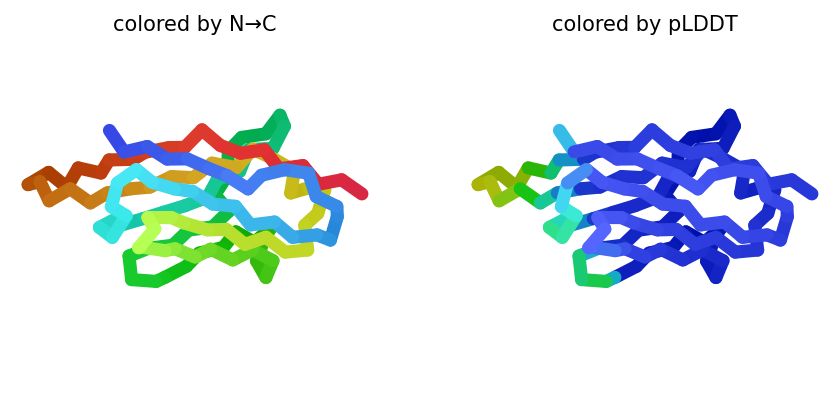

2026-03-06 15:21:23,767 deepfold_v1_model_2_seed_002 recycle=0 pLDDT=90
2026-03-06 15:21:32,715 deepfold_v1_model_2_seed_002 recycle=1 pLDDT=91.2 tol=0.215
2026-03-06 15:21:41,687 deepfold_v1_model_2_seed_002 recycle=2 pLDDT=90.7 tol=0.206
2026-03-06 15:21:50,691 deepfold_v1_model_2_seed_002 recycle=3 pLDDT=90.2 tol=0.0791
2026-03-06 15:21:59,718 deepfold_v1_model_2_seed_002 recycle=4 pLDDT=90.4 tol=0.0923
2026-03-06 15:22:08,724 deepfold_v1_model_2_seed_002 recycle=5 pLDDT=90.4 tol=0.0916
2026-03-06 15:22:17,683 deepfold_v1_model_2_seed_002 recycle=6 pLDDT=90.3 tol=0.116
2026-03-06 15:22:17,683 deepfold_v1_model_2_seed_002 took 62.8s (6 recycles)


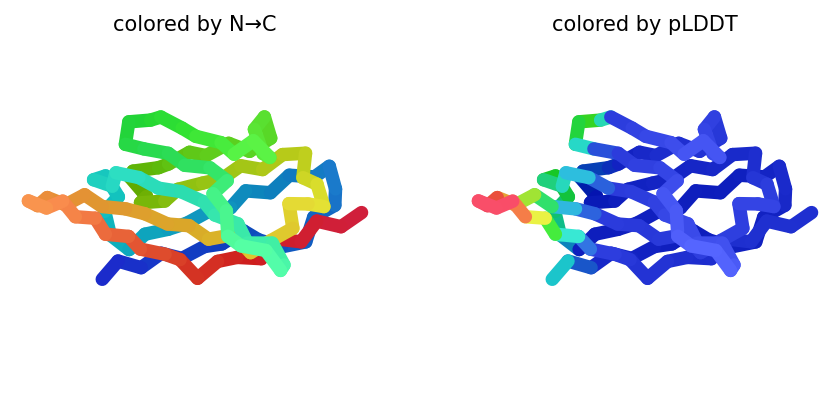

2026-03-06 15:22:26,632 deepfold_v1_model_3_seed_002 recycle=0 pLDDT=89
2026-03-06 15:22:35,469 deepfold_v1_model_3_seed_002 recycle=1 pLDDT=90.3 tol=0.284
2026-03-06 15:22:44,268 deepfold_v1_model_3_seed_002 recycle=2 pLDDT=90 tol=0.182
2026-03-06 15:22:53,066 deepfold_v1_model_3_seed_002 recycle=3 pLDDT=90.1 tol=0.118
2026-03-06 15:23:01,841 deepfold_v1_model_3_seed_002 recycle=4 pLDDT=90.4 tol=0.117
2026-03-06 15:23:10,620 deepfold_v1_model_3_seed_002 recycle=5 pLDDT=90.9 tol=0.103
2026-03-06 15:23:19,367 deepfold_v1_model_3_seed_002 recycle=6 pLDDT=90.6 tol=0.0996
2026-03-06 15:23:19,368 deepfold_v1_model_3_seed_002 took 61.6s (6 recycles)


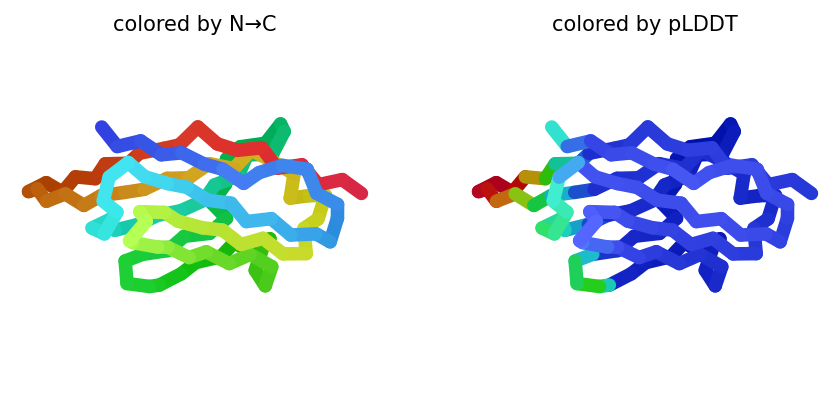

2026-03-06 15:23:28,235 deepfold_v1_model_4_seed_002 recycle=0 pLDDT=88.6
2026-03-06 15:23:36,940 deepfold_v1_model_4_seed_002 recycle=1 pLDDT=90.5 tol=0.439
2026-03-06 15:23:45,640 deepfold_v1_model_4_seed_002 recycle=2 pLDDT=89.7 tol=0.23
2026-03-06 15:23:54,335 deepfold_v1_model_4_seed_002 recycle=3 pLDDT=89.6 tol=0.13
2026-03-06 15:24:03,031 deepfold_v1_model_4_seed_002 recycle=4 pLDDT=89.9 tol=0.104
2026-03-06 15:24:11,708 deepfold_v1_model_4_seed_002 recycle=5 pLDDT=90.1 tol=0.088
2026-03-06 15:24:20,391 deepfold_v1_model_4_seed_002 recycle=6 pLDDT=89.8 tol=0.0924
2026-03-06 15:24:20,391 deepfold_v1_model_4_seed_002 took 60.9s (6 recycles)


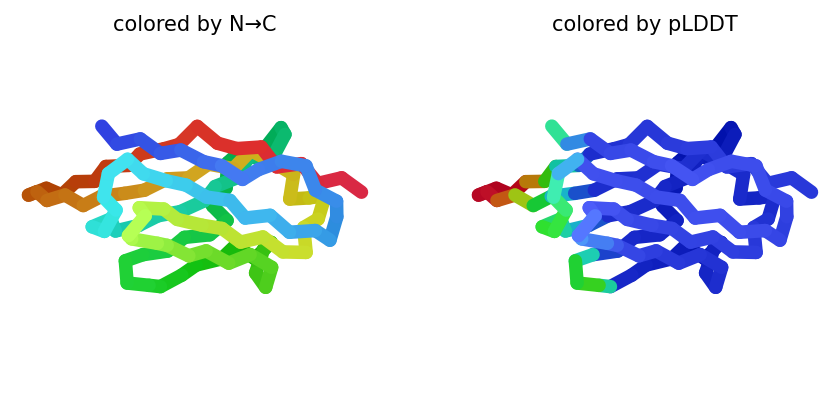

2026-03-06 15:24:29,215 deepfold_v1_model_5_seed_002 recycle=0 pLDDT=88.6
2026-03-06 15:24:37,875 deepfold_v1_model_5_seed_002 recycle=1 pLDDT=90.8 tol=0.528
2026-03-06 15:24:46,520 deepfold_v1_model_5_seed_002 recycle=2 pLDDT=89.8 tol=0.257
2026-03-06 15:24:55,165 deepfold_v1_model_5_seed_002 recycle=3 pLDDT=89.6 tol=0.124
2026-03-06 15:25:03,832 deepfold_v1_model_5_seed_002 recycle=4 pLDDT=89.9 tol=0.0997
2026-03-06 15:25:12,493 deepfold_v1_model_5_seed_002 recycle=5 pLDDT=90.1 tol=0.103
2026-03-06 15:25:21,150 deepfold_v1_model_5_seed_002 recycle=6 pLDDT=89.8 tol=0.0939
2026-03-06 15:25:21,150 deepfold_v1_model_5_seed_002 took 60.6s (6 recycles)


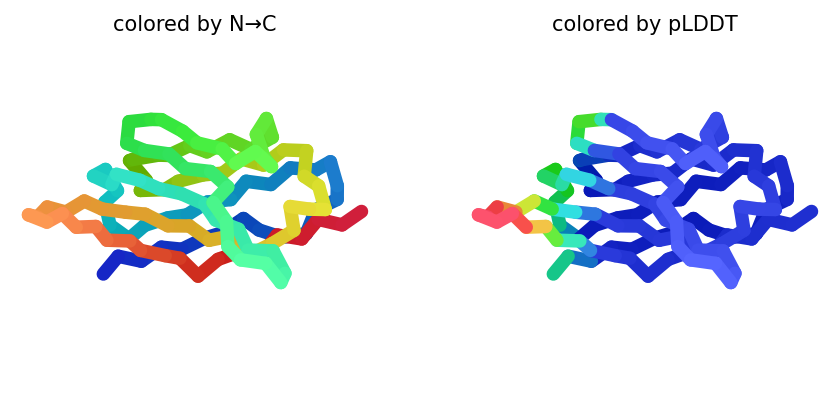

2026-03-06 15:25:37,029 deepfold_v1_model_1_seed_003 recycle=0 pLDDT=91.6
2026-03-06 15:25:45,647 deepfold_v1_model_1_seed_003 recycle=1 pLDDT=91.5 tol=0.195
2026-03-06 15:25:54,267 deepfold_v1_model_1_seed_003 recycle=2 pLDDT=91.6 tol=0.155
2026-03-06 15:26:02,932 deepfold_v1_model_1_seed_003 recycle=3 pLDDT=91.8 tol=0.0946
2026-03-06 15:26:11,586 deepfold_v1_model_1_seed_003 recycle=4 pLDDT=91.8 tol=0.083
2026-03-06 15:26:20,247 deepfold_v1_model_1_seed_003 recycle=5 pLDDT=91.9 tol=0.0826
2026-03-06 15:26:28,915 deepfold_v1_model_1_seed_003 recycle=6 pLDDT=92.3 tol=0.1
2026-03-06 15:26:28,916 deepfold_v1_model_1_seed_003 took 60.6s (6 recycles)


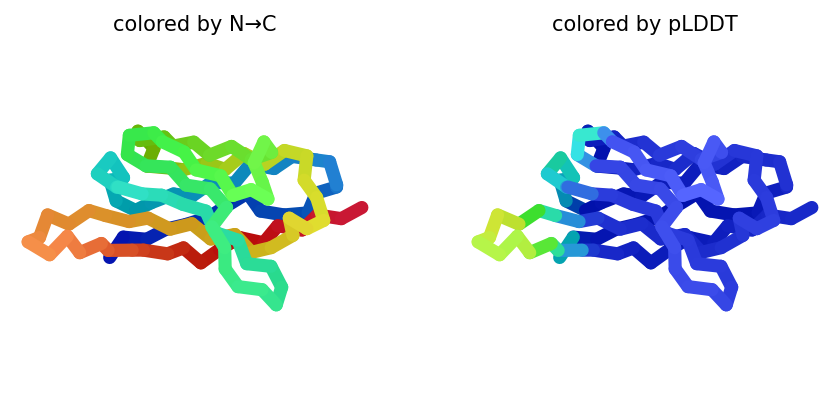

2026-03-06 15:26:37,687 deepfold_v1_model_2_seed_003 recycle=0 pLDDT=90.2
2026-03-06 15:26:46,348 deepfold_v1_model_2_seed_003 recycle=1 pLDDT=90 tol=0.164
2026-03-06 15:26:55,016 deepfold_v1_model_2_seed_003 recycle=2 pLDDT=90.2 tol=0.124
2026-03-06 15:27:03,691 deepfold_v1_model_2_seed_003 recycle=3 pLDDT=90.2 tol=0.108
2026-03-06 15:27:12,342 deepfold_v1_model_2_seed_003 recycle=4 pLDDT=90.2 tol=0.0968
2026-03-06 15:27:21,031 deepfold_v1_model_2_seed_003 recycle=5 pLDDT=90.4 tol=0.0981
2026-03-06 15:27:29,712 deepfold_v1_model_2_seed_003 recycle=6 pLDDT=90.8 tol=0.0941
2026-03-06 15:27:29,712 deepfold_v1_model_2_seed_003 took 60.7s (6 recycles)


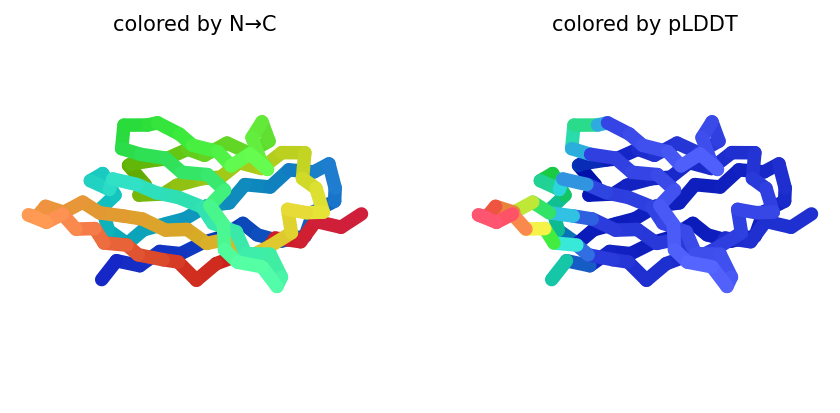

2026-03-06 15:27:38,408 deepfold_v1_model_3_seed_003 recycle=0 pLDDT=90.2
2026-03-06 15:27:47,022 deepfold_v1_model_3_seed_003 recycle=1 pLDDT=89.4 tol=0.492
2026-03-06 15:27:55,628 deepfold_v1_model_3_seed_003 recycle=2 pLDDT=89.4 tol=0.158
2026-03-06 15:28:04,237 deepfold_v1_model_3_seed_003 recycle=3 pLDDT=90.1 tol=0.234
2026-03-06 15:28:12,864 deepfold_v1_model_3_seed_003 recycle=4 pLDDT=90.1 tol=0.192
2026-03-06 15:28:21,485 deepfold_v1_model_3_seed_003 recycle=5 pLDDT=90.6 tol=0.118
2026-03-06 15:28:30,088 deepfold_v1_model_3_seed_003 recycle=6 pLDDT=91.1 tol=0.0941
2026-03-06 15:28:30,089 deepfold_v1_model_3_seed_003 took 60.3s (6 recycles)


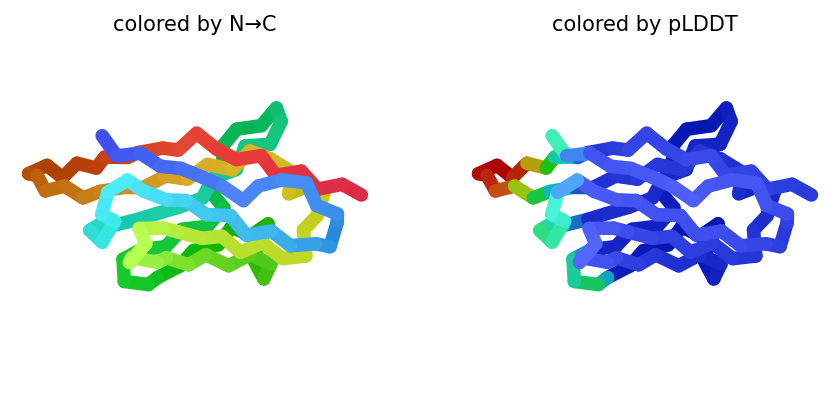

2026-03-06 15:28:38,788 deepfold_v1_model_4_seed_003 recycle=0 pLDDT=89.1
2026-03-06 15:28:47,396 deepfold_v1_model_4_seed_003 recycle=1 pLDDT=88.4 tol=0.452
2026-03-06 15:28:55,980 deepfold_v1_model_4_seed_003 recycle=2 pLDDT=88.6 tol=0.202
2026-03-06 15:29:04,588 deepfold_v1_model_4_seed_003 recycle=3 pLDDT=89.2 tol=0.254
2026-03-06 15:29:13,182 deepfold_v1_model_4_seed_003 recycle=4 pLDDT=89.1 tol=0.185
2026-03-06 15:29:21,806 deepfold_v1_model_4_seed_003 recycle=5 pLDDT=89.7 tol=0.159
2026-03-06 15:29:30,428 deepfold_v1_model_4_seed_003 recycle=6 pLDDT=90 tol=0.0955
2026-03-06 15:29:30,428 deepfold_v1_model_4_seed_003 took 60.2s (6 recycles)


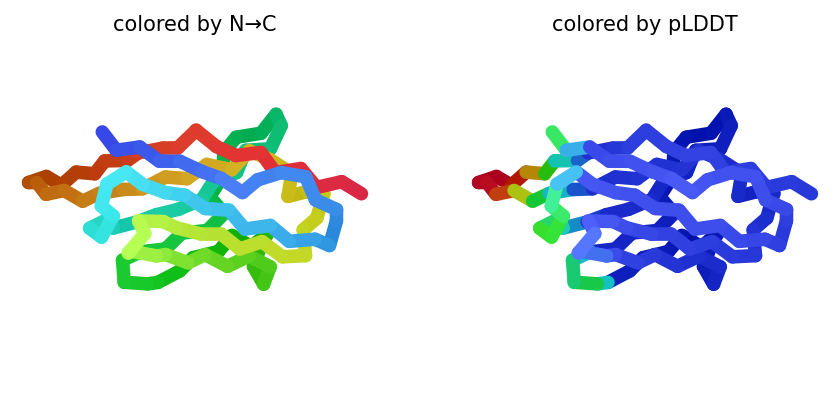

2026-03-06 15:29:39,192 deepfold_v1_model_5_seed_003 recycle=0 pLDDT=89.6
2026-03-06 15:29:47,804 deepfold_v1_model_5_seed_003 recycle=1 pLDDT=88.6 tol=0.52
2026-03-06 15:29:56,422 deepfold_v1_model_5_seed_003 recycle=2 pLDDT=88.5 tol=0.241
2026-03-06 15:30:05,039 deepfold_v1_model_5_seed_003 recycle=3 pLDDT=89.7 tol=0.303
2026-03-06 15:30:13,645 deepfold_v1_model_5_seed_003 recycle=4 pLDDT=89 tol=0.192
2026-03-06 15:30:22,242 deepfold_v1_model_5_seed_003 recycle=5 pLDDT=89.6 tol=0.18
2026-03-06 15:30:30,868 deepfold_v1_model_5_seed_003 recycle=6 pLDDT=90 tol=0.0974
2026-03-06 15:30:30,869 deepfold_v1_model_5_seed_003 took 60.3s (6 recycles)


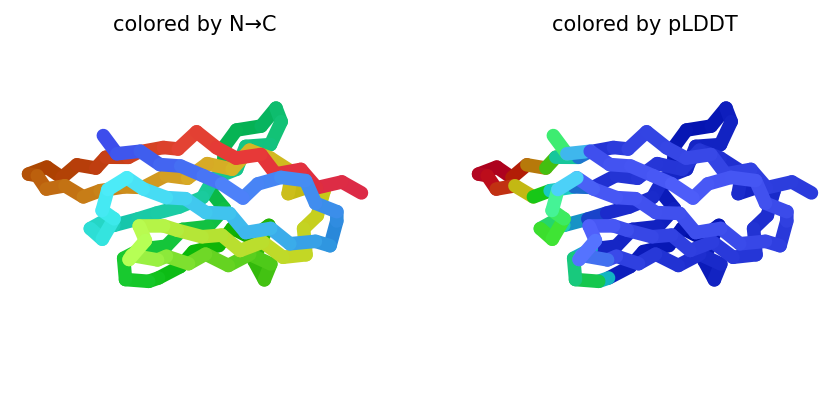

2026-03-06 15:30:30,978 reranking models by 'plddt' metric
2026-03-06 15:30:39,150 Relaxation took 8.2s
2026-03-06 15:30:39,151 rank_001_deepfold_v1_model_3_seed_001 pLDDT=94.6
2026-03-06 15:30:44,750 Relaxation took 5.6s
2026-03-06 15:30:44,751 rank_002_deepfold_v1_model_5_seed_001 pLDDT=94.1
2026-03-06 15:30:49,508 Relaxation took 4.8s
2026-03-06 15:30:49,508 rank_003_deepfold_v1_model_4_seed_001 pLDDT=93.4
2026-03-06 15:30:53,552 Relaxation took 4.0s
2026-03-06 15:30:53,553 rank_004_deepfold_v1_model_1_seed_003 pLDDT=92.3
2026-03-06 15:30:58,096 Relaxation took 4.5s
2026-03-06 15:30:58,096 rank_005_deepfold_v1_model_1_seed_001 pLDDT=92
2026-03-06 15:30:58,097 rank_006_deepfold_v1_model_1_seed_002 pLDDT=91.8
2026-03-06 15:30:58,097 rank_007_deepfold_v1_model_1_seed_000 pLDDT=91.8
2026-03-06 15:30:58,098 rank_008_deepfold_v1_model_3_seed_003 pLDDT=91.1
2026-03-06 15:30:58,098 rank_009_deepfold_v1_model_2_seed_003 pLDDT=90.8
2026-03-06 15:30:58,098 rank_010_deepfold_v1_model_3_seed_002

0

In [46]:
#@title Run Prediction
display_images = True #@param {type:"boolean"}

import sys
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from Bio import BiopythonDeprecationWarning
warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
from pathlib import Path
from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2

import os
import numpy as np
try:
  K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
except:
  K80_chk = "0"
  pass
if "1" in K80_chk:
  print("WARNING: found GPU Tesla K80: limited to total length < 1000")
  if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
    del os.environ["TF_FORCE_UNIFIED_MEMORY"]
  if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
    del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]

from colabfold.colabfold import plot_protein
from pathlib import Path
import matplotlib.pyplot as plt

# For some reason we need that to get pdbfixer to import
if use_amber and f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
    sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")

def input_features_callback(input_features):
  if display_images:
    plot_msa_v2(input_features)
    plt.show()
    plt.close()

def prediction_callback(protein_obj, length,
                        prediction_result, input_features, mode):
  model_name, relaxed = mode
  if not relaxed:
    if display_images:
      fig = plot_protein(protein_obj, Ls=length, dpi=150)
      plt.show()
      plt.close()

result_dir = jobname
log_filename = os.path.join(jobname,"log.txt")
setup_logging(Path(log_filename))

queries, is_complex = get_queries(queries_path)
model_type = set_model_type(is_complex, model_type)

if "multimer" in model_type and max_msa is not None:
  use_cluster_profile = False
else:
  use_cluster_profile = True

download_alphafold_params(model_type, Path("."))
results = run(
    queries=queries,
    result_dir=result_dir,
    use_templates=use_templates,
    custom_template_path=custom_template_path,
    num_relax=num_relax,
    msa_mode=msa_mode,
    model_type=model_type,
    num_models=5,
    num_recycles=num_recycles,
    relax_max_iterations=relax_max_iterations,
    recycle_early_stop_tolerance=recycle_early_stop_tolerance,
    num_seeds=num_seeds,
    use_dropout=use_dropout,
    model_order=[1,2,3,4,5],
    is_complex=is_complex,
    data_dir=Path("."),
    keep_existing_results=False,
    rank_by="auto",
    pair_mode=pair_mode,
    pairing_strategy=pairing_strategy,
    stop_at_score=float(100),
    prediction_callback=prediction_callback,
    dpi=dpi,
    zip_results=False,
    save_all=save_all,
    max_msa=max_msa,
    use_cluster_profile=use_cluster_profile,
    input_features_callback=input_features_callback,
    save_recycles=save_recycles,
    user_agent="colabfold/google-colab-main",
    calc_extra_ptm=calc_extra_ptm,
)
results_zip = f"{jobname}.result.zip"
os.system(f"zip -r {results_zip} {jobname}")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

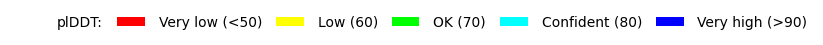

In [47]:
#@title Display 3D structure {run: "auto"}
import py3Dmol
import glob
import matplotlib.pyplot as plt
from colabfold.colabfold import plot_plddt_legend
from colabfold.colabfold import pymol_color_list, alphabet_list
rank_num = 1 #@param ["1", "2", "3", "4", "5"] {type:"raw"}
color = "lDDT" #@param ["chain", "lDDT", "rainbow"]
show_sidechains = True #@param {type:"boolean"}
show_mainchains = True #@param {type:"boolean"}

tag = results["rank"][0][rank_num - 1]
jobname_prefix = ".custom" if msa_mode == "custom" else ""
pdb_filename = f"{jobname}/{jobname}{jobname_prefix}_unrelaxed_{tag}.pdb"
pdb_file = glob.glob(pdb_filename)

def show_pdb(rank_num=1, show_sidechains=False, show_mainchains=False, color="lDDT"):
  model_name = f"rank_{rank_num}"
  view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js',)
  view.addModel(open(pdb_file[0],'r').read(),'pdb')

  if color == "lDDT":
    view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':50,'max':90}}})
  elif color == "rainbow":
    view.setStyle({'cartoon': {'color':'spectrum'}})
  elif color == "chain":
    chains = len(queries[0][1]) + 1 if is_complex else 1
    for n,chain,color in zip(range(chains),alphabet_list,pymol_color_list):
       view.setStyle({'chain':chain},{'cartoon': {'color':color}})

  if show_sidechains:
    BB = ['C','O','N']
    view.addStyle({'and':[{'resn':["GLY","PRO"],'invert':True},{'atom':BB,'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"GLY"},{'atom':'CA'}]},
                        {'sphere':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
  if show_mainchains:
    BB = ['C','O','N','CA']
    view.addStyle({'atom':BB},{'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

  view.zoomTo()
  return view

show_pdb(rank_num, show_sidechains, show_mainchains, color).show()
if color == "lDDT":
  plot_plddt_legend().show()


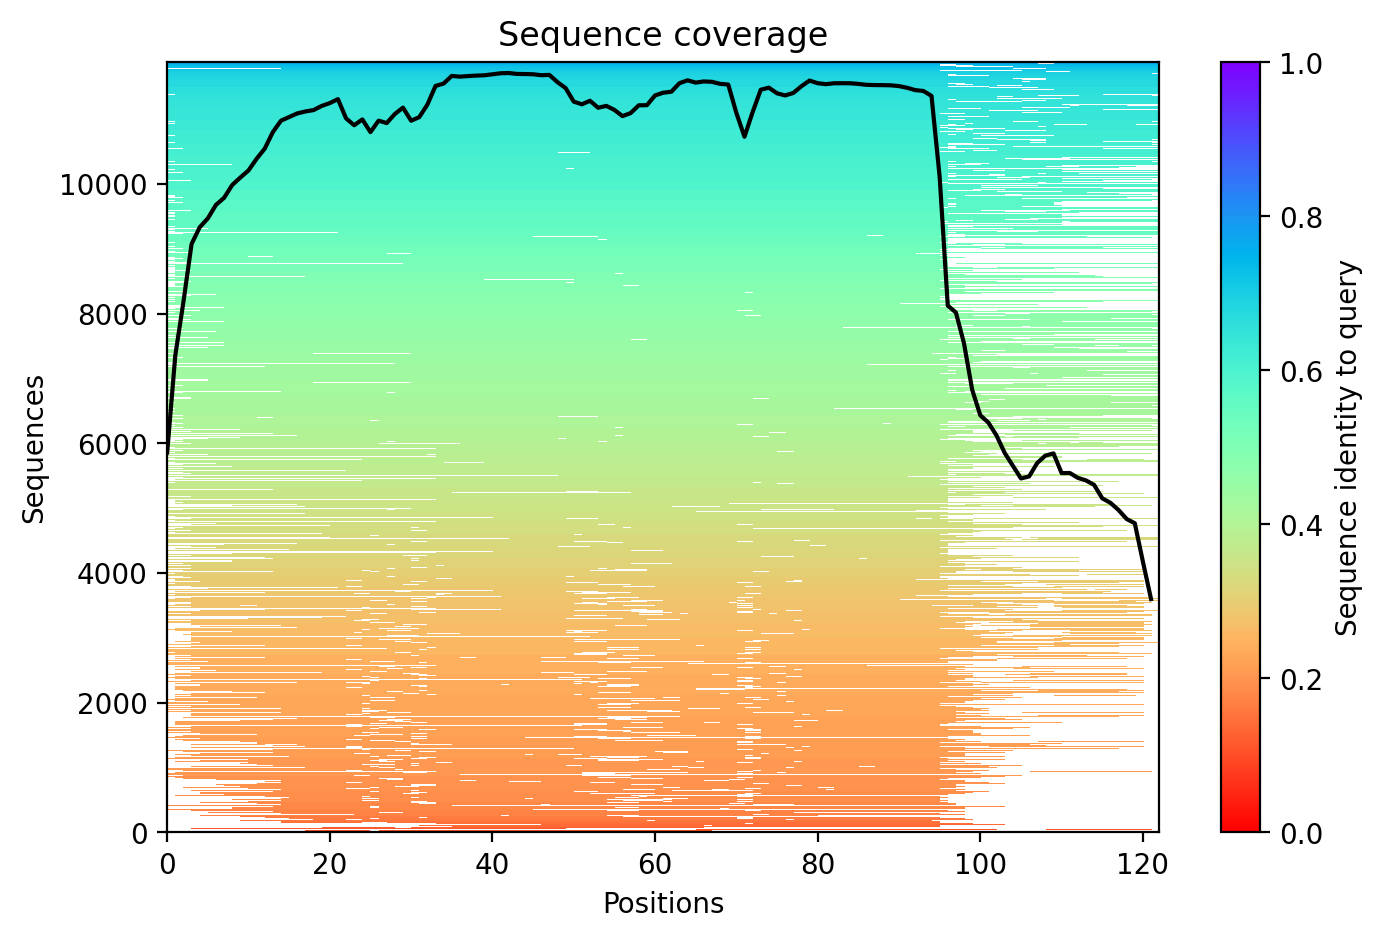
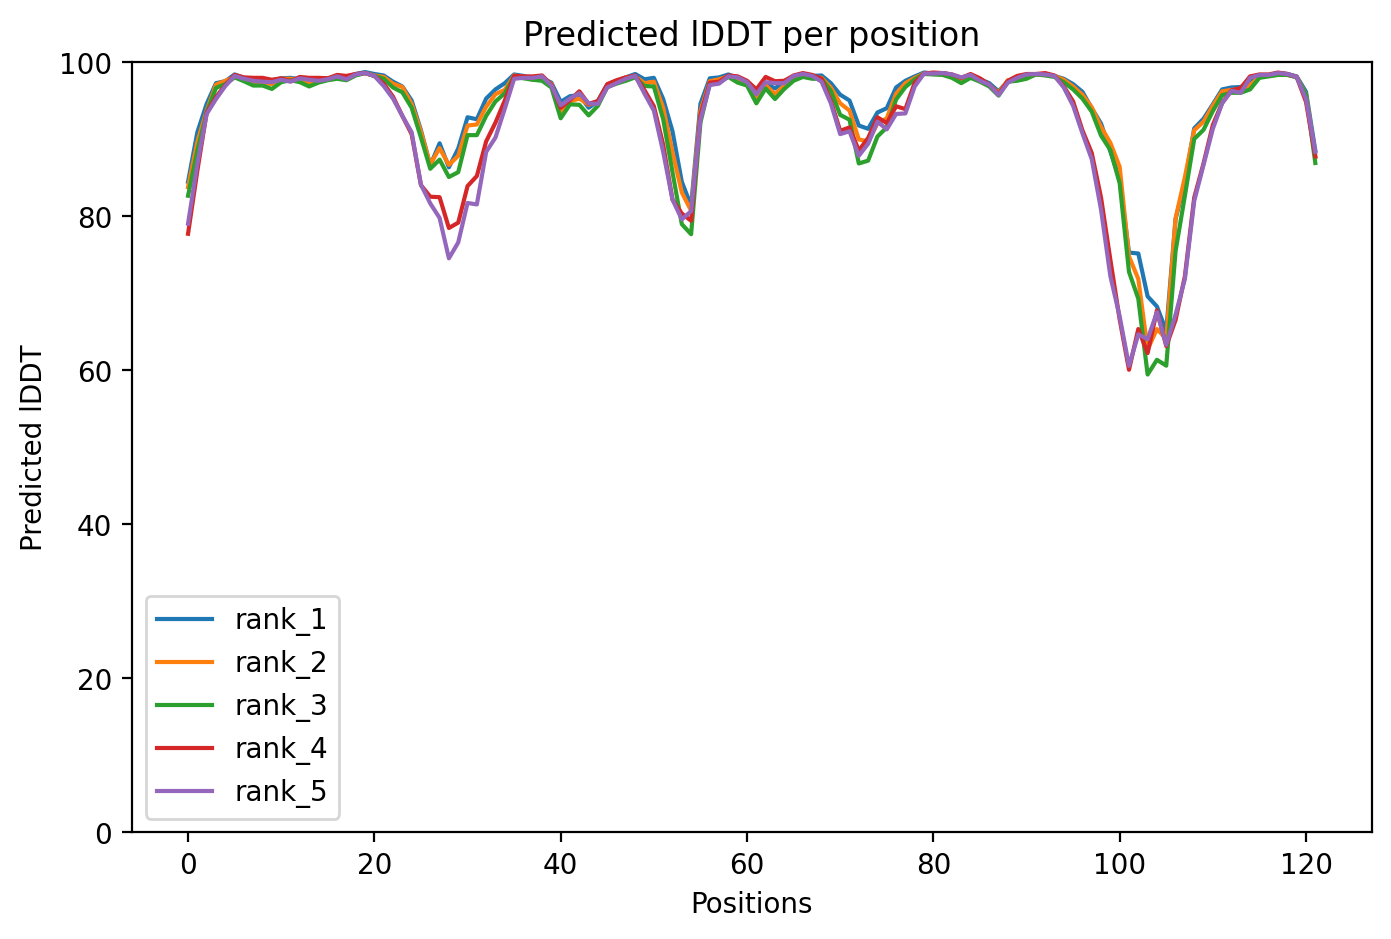

In [48]:
#@title Plots {run: "auto"}
from IPython.display import display, HTML
import base64
from html import escape

# see: https://stackoverflow.com/a/53688522
def image_to_data_url(filename):
  ext = filename.split('.')[-1]
  prefix = f'data:image/{ext};base64,'
  with open(filename, 'rb') as f:
    img = f.read()
  return prefix + base64.b64encode(img).decode('utf-8')

pae = ""
pae_file = os.path.join(jobname,f"{jobname}{jobname_prefix}_pae.png")
if os.path.isfile(pae_file):
    pae = image_to_data_url(pae_file)
cov = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_coverage.png"))
plddt = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_plddt.png"))
display(HTML(f"""
<style>
  img {{
    float:left;
  }}
  .full {{
    max-width:100%;
  }}
  .half {{
    max-width:50%;
  }}
  @media (max-width:640px) {{
    .half {{
      max-width:100%;
    }}
  }}
</style>
<div style="max-width:90%; padding:2em;">
  <h1>Plots for {escape(jobname)}</h1>
  { '<!--' if pae == '' else '' }<img src="{pae}" class="full" />{ '-->' if pae == '' else '' }
  <img src="{cov}" class="half" />
  <img src="{plddt}" class="half" />
</div>
"""))

In [49]:
#@title Package and download results
#@markdown If you are having issues downloading the result archive, try disabling your adblocker and run this cell again. If that fails click on the little folder icon to the left, navigate to file: `jobname.result.zip`, right-click and select \"Download\" (see [screenshot](https://pbs.twimg.com/media/E6wRW2lWUAEOuoe?format=jpg&name=small)).

if msa_mode == "custom":
  print("Don't forget to cite your custom MSA generation method.")

files.download(f"{jobname}.result.zip")

if save_to_google_drive == True and drive:
  uploaded = drive.CreateFile({'title': f"{jobname}.result.zip"})
  uploaded.SetContentFile(f"{jobname}.result.zip")
  uploaded.Upload()
  print(f"Uploaded {jobname}.result.zip to Google Drive with ID {uploaded.get('id')}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Instructions <a name="Instructions"></a>
For detailed instructions, tips and tricks, see recently published paper at [Nature Protocols](https://www.nature.com/articles/s41596-024-01060-5)

**Quick start**
1. Paste your protein sequence(s) in the input field.
2. Press "Runtime" -> "Run all".
3. The pipeline consists of 5 steps. The currently running step is indicated by a circle with a stop sign next to it.

**Result zip file contents**

1. PDB formatted structures sorted by avg. pLDDT and complexes are sorted by pTMscore. (unrelaxed and relaxed if `use_amber` is enabled).
2. Plots of the model quality.
3. Plots of the MSA coverage.
4. Parameter log file.
5. A3M formatted input MSA.
6. A `predicted_aligned_error_v1.json` using [AlphaFold-DB's format](https://alphafold.ebi.ac.uk/faq#faq-7) and a `scores.json` for each model which contains an array (list of lists) for PAE, a list with the average pLDDT and the pTMscore.
7. BibTeX file with citations for all used tools and databases.

At the end of the job a download modal box will pop up with a `jobname.result.zip` file. Additionally, if the `save_to_google_drive` option was selected, the `jobname.result.zip` will be uploaded to your Google Drive.

**MSA generation for complexes**

For the complex prediction we use unpaired and paired MSAs. Unpaired MSA is generated the same way as for the protein structures prediction by searching the UniRef100 and environmental sequences three iterations each.

The paired MSA is generated by searching the UniRef100 database and pairing the best hits sharing the same NCBI taxonomic identifier (=species or sub-species). We only pair sequences if all of the query sequences are present for the respective taxonomic identifier.

**Using a custom MSA as input**

To predict the structure with a custom MSA (A3M formatted): (1) Change the `msa_mode`: to "custom", (2) Wait for an upload box to appear at the end of the "MSA options ..." box. Upload your A3M. The first fasta entry of the A3M must be the query sequence without gaps.

It is also possilbe to provide custom MSAs for complex predictions. Read more about the format [here](https://github.com/sokrypton/ColabFold/issues/76).

As an alternative for MSA generation the [HHblits Toolkit server](https://toolkit.tuebingen.mpg.de/tools/hhblits) can be used. After submitting your query, click "Query Template MSA" -> "Download Full A3M". Download the A3M file and upload it in this notebook.

**PDB100** <a name="pdb100"></a>

As of 23/06/08, we have transitioned from using the PDB70 to a 100% clustered PDB, the PDB100. The construction methodology of PDB100 differs from that of PDB70.

The PDB70 was constructed by running each PDB70 representative sequence through [HHblits](https://github.com/soedinglab/hh-suite) against the [Uniclust30](https://uniclust.mmseqs.com/). On the other hand, the PDB100 is built by searching each PDB100 representative structure with [Foldseek](https://github.com/steineggerlab/foldseek) against the [AlphaFold Database](https://alphafold.ebi.ac.uk).

To maintain compatibility with older Notebook versions and local installations, the generated files and API responses will continue to be named "PDB70", even though we're now using the PDB100.

**Using custom templates** <a name="custom_templates"></a>

To predict the structure with a custom template (PDB or mmCIF formatted): (1) change the `template_mode` to "custom" in the execute cell and (2) wait for an upload box to appear at the end of the "Input Protein" box. Select and upload your templates (multiple choices are possible).

* Templates must follow the four letter PDB naming with lower case letters.

* Templates in mmCIF format must contain `_entity_poly_seq`. An error is thrown if this field is not present. The field `_pdbx_audit_revision_history.revision_date` is automatically generated if it is not present.

* Templates in PDB format are automatically converted to the mmCIF format. `_entity_poly_seq` and `_pdbx_audit_revision_history.revision_date` are automatically generated.

If you encounter problems, please report them to this [issue](https://github.com/sokrypton/ColabFold/issues/177).

**Comparison to the full AlphaFold2 and AlphaFold2 Colab**

This notebook replaces the homology detection and MSA pairing of AlphaFold2 with MMseqs2. For a comparison against the [AlphaFold2 Colab](https://colab.research.google.com/github/deepmind/alphafold/blob/main/notebooks/AlphaFold.ipynb) and the full [AlphaFold2](https://github.com/deepmind/alphafold) system read our [paper](https://www.nature.com/articles/s41592-022-01488-1).

**Troubleshooting**
* Check that the runtime type is set to GPU at "Runtime" -> "Change runtime type".
* Try to restart the session "Runtime" -> "Factory reset runtime".
* Check your input sequence.

**Known issues**
* Google Colab assigns different types of GPUs with varying amount of memory. Some might not have enough memory to predict the structure for a long sequence.
* Your browser can block the pop-up for downloading the result file. You can choose the `save_to_google_drive` option to upload to Google Drive instead or manually download the result file: Click on the little folder icon to the left, navigate to file: `jobname.result.zip`, right-click and select \"Download\" (see [screenshot](https://pbs.twimg.com/media/E6wRW2lWUAEOuoe?format=jpg&name=small)).

**Limitations**
* Computing resources: Our MMseqs2 API can handle ~20-50k requests per day.
* MSAs: MMseqs2 is very precise and sensitive but might find less hits compared to HHblits/HMMer searched against BFD or MGnify.
* We recommend to additionally use the full [AlphaFold2 pipeline](https://github.com/deepmind/alphafold).

**Description of the plots**
*   **Number of sequences per position** - We want to see at least 30 sequences per position, for best performance, ideally 100 sequences.
*   **Predicted lDDT per position** - model confidence (out of 100) at each position. The higher the better.
*   **Predicted Alignment Error** - For homooligomers, this could be a useful metric to assess how confident the model is about the interface. The lower the better.

**Bugs**
- If you encounter any bugs, please report the issue to https://github.com/sokrypton/ColabFold/issues

**License**

The source code of ColabFold is licensed under [MIT](https://raw.githubusercontent.com/sokrypton/ColabFold/main/LICENSE). Additionally, this notebook uses the AlphaFold2 source code and its parameters licensed under [Apache 2.0](https://raw.githubusercontent.com/deepmind/alphafold/main/LICENSE) and [CC BY 4.0](https://creativecommons.org/licenses/by-sa/4.0/) respectively. Read more about the AlphaFold license [here](https://github.com/deepmind/alphafold).

**Acknowledgments**
- We thank the AlphaFold team for developing an excellent model and open sourcing the software.

- [KOBIC](https://kobic.re.kr) and [Söding Lab](https://www.mpinat.mpg.de/soeding) for providing the computational resources for the MMseqs2 MSA server.

- Richard Evans for helping to benchmark the ColabFold's Alphafold-multimer support.

- [David Koes](https://github.com/dkoes) for his awesome [py3Dmol](https://3dmol.csb.pitt.edu/) plugin, without whom these notebooks would be quite boring!

- Do-Yoon Kim for creating the ColabFold logo.

- A colab by Sergey Ovchinnikov ([@sokrypton](https://twitter.com/sokrypton)), Milot Mirdita ([@milot_mirdita](https://twitter.com/milot_mirdita)) and Martin Steinegger ([@thesteinegger](https://twitter.com/thesteinegger)).
